In [1]:
import os, gc, json, time, random, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset
from collections import Counter

from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

os.makedirs("../results/models", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

Device: cuda


In [2]:
train_df = pd.read_csv("../data/processed/train_hard2.csv")
test_df  = pd.read_csv("../data/processed/test_hard2.csv")

labels = sorted(train_df["label"].unique().tolist())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Labels: {label2id}")

Train: (4898, 6) | Test: (2107, 6)
Labels: {'normal': 0, 'promo': 1, 'smish': 2}


In [3]:
t0 = time.time()

# Cluster
vec_campaign = TfidfVectorizer(
    analyzer="char_wb", ngram_range=(3,6),
    max_features=20000, min_df=2, sublinear_tf=True,
)
X_campaign = vec_campaign.fit_transform(train_df["text_clean"].astype(str))

kmeans = KMeans(n_clusters=150, random_state=SEED, n_init=10)
train_df = train_df.copy()
train_df["cluster"] = kmeans.fit_predict(X_campaign)

# GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(train_df, groups=train_df["cluster"]))

train_split = train_df.iloc[train_idx].reset_index(drop=True)
val_split   = train_df.iloc[val_idx].reset_index(drop=True)

# Strict near-dup filter
vec_word = TfidfVectorizer(analyzer='word', ngram_range=(1,3), min_df=2,
                            max_features=15000, sublinear_tf=True)
vec_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2,
                            max_features=15000, sublinear_tf=True)

X_train_w = vec_word.fit_transform(train_split["text_clean"].astype(str))
X_val_w   = vec_word.transform(val_split["text_clean"].astype(str))
X_train_c = vec_char.fit_transform(train_split["text_clean"].astype(str))
X_val_c   = vec_char.transform(val_split["text_clean"].astype(str))

sim_w = cosine_similarity(X_val_w, X_train_w).max(axis=1)
sim_c = cosine_similarity(X_val_c, X_train_c).max(axis=1)

keep_mask = (sim_w < 0.55) & (sim_c < 0.80)
val_split_clean = val_split[keep_mask].reset_index(drop=True)

print(f"[{time.time()-t0:.1f}s] Train: {train_split.shape} | Val: {len(val_split_clean)}")

# Augmentation
def augment(text):
    if "[URL]" in text and random.random() < 0.5:
        text = text.replace("[URL]", "").strip()
    if "[PHONE]" in text and random.random() < 0.5:
        text = text.replace("[PHONE]", "").strip()
    words = text.split()
    if len(words) > 5 and random.random() < 0.2:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
        text = " ".join(words)
    return text

random.seed(SEED)
aug_rows = []
for _, row in train_split.iterrows():
    for _ in range(2):
        new_row = row.copy()
        new_text = augment(row["text_clean"])
        if new_text != row["text_clean"]:
            new_row["text_clean"] = new_text
            aug_rows.append(new_row)

train_aug = pd.concat([train_split, pd.DataFrame(aug_rows)], ignore_index=True)
train_aug = train_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Augmented train: {train_aug.shape}")

[83.7s] Train: (4065, 7) | Val: 623
Augmented train: (6798, 7)


In [4]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

class SMSDataset(Dataset):
    def __init__(self, df, tokenizer, label2id, max_len=128):
        self.texts = df["text_clean"].astype(str).tolist()
        self.labels = [label2id[l] for l in df["label"]]
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True,
                              padding="max_length", max_length=self.max_len)
        enc["labels"] = self.labels[idx]
        return enc

train_ds = SMSDataset(train_aug, tokenizer, label2id, MAX_LEN)
val_ds   = SMSDataset(val_split_clean, tokenizer, label2id, MAX_LEN)
test_ds  = SMSDataset(test_df, tokenizer, label2id, MAX_LEN)

# Class weights
label_counts = Counter(train_aug["label"].map(label2id))
total = sum(label_counts.values())
class_weights = {i: total / (len(labels) * label_counts[i]) for i in range(len(labels))}

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print("Class weights:", class_weights)

Train: 6798 | Val: 623 | Test: 2107
Class weights: {0: 1.0361225422953817, 1: 1.2416438356164383, 2: 0.8133524766690596}


In [5]:
def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        y = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = torch.tensor([self.class_weights[i] for i in range(len(self.class_weights))],
                          device=logits.device, dtype=torch.float32)
        loss = nn.CrossEntropyLoss(weight=w)(logits, y)
        return (loss, outputs) if return_outputs else loss


def run_ablation(r_value):
    """r value দিয়ে full pipeline চালায় এবং result রিটার্ন করে"""
    print("\n" + "="*70)
    print(f"RUNNING ABLATION: LoRA r = {r_value}")
    print("="*70)

    # Clean memory
    gc.collect()
    torch.cuda.empty_cache()

    # Check GPU free memory
    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        print(f"GPU Free: {free/1e9:.2f} GB / {total/1e9:.2f} GB")

    # Base model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(labels),
        id2label=id2label, label2id=label2id,
    )

    # LoRA config with variable r
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r_value,
        lora_alpha=r_value * 2,
        lora_dropout=0.2,
        bias="none",
        target_modules=["query", "key", "value", "dense"],
    )
    model = get_peft_model(base_model, lora_config)

    # Trainable params
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    pct = trainable / total_params * 100
    print(f"Trainable: {trainable:,} ({pct:.3f}%)")

    # ====================================================
    # ⚡ OPTIMIZED TRAINING ARGUMENTS
    # ====================================================
    training_args = TrainingArguments(
        output_dir=f"../results/models/lora_r{r_value}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,         # 8 → 16
        per_device_eval_batch_size=32,           # 16 → 32
        gradient_accumulation_steps=1,           # 2 → 1
        num_train_epochs=3,                      # 5 → 3
        weight_decay=0.05,
        warmup_steps=0.2,
        max_grad_norm=0.5,
        label_smoothing_factor=0.1,
        lr_scheduler_type="cosine",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_macro_f1",
        greater_is_better=True,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        fp16=True,                               # ⚡ Forced True
        optim="adamw_torch_fused",               # ⚡ Fast optimizer
        dataloader_num_workers=0,                # Windows-safe
        dataloader_pin_memory=True,              # ⚡ Fast GPU transfer
        seed=SEED,
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.001)],
    )

    # Train
    trainer.train()

    # Test
    test_results = trainer.evaluate(test_ds, metric_key_prefix="test")
    preds_output = trainer.predict(test_ds)
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    y_true = preds_output.label_ids

    smish_idx = label2id["smish"]
    smish_mask = y_true == smish_idx
    smish_recall = (y_pred[smish_mask] == smish_idx).mean()

    result = {
        "r": r_value,
        "trainable_params": trainable,
        "trainable_pct": pct,
        "val_f1": float(trainer.state.best_metric) if trainer.state.best_metric else None,
        "test_f1": float(test_results["test_macro_f1"]),
        "test_acc": float(test_results["test_accuracy"]),
        "smish_recall": float(smish_recall),
    }

    print(f"\n✅ r={r_value} | Test F1={result['test_f1']:.4f} | Smish Rec={result['smish_recall']:.4f}")

    # Cleanup before next run
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

    return result


print("✅ Function ready (OPTIMIZED). Run Cell A6 to execute.")

✅ Function ready (OPTIMIZED). Run Cell A6 to execute.


In [9]:
all_results = []
for r in [8, 16, 32]:
    result = run_ablation(r)
    all_results.append(result)
    print(f"\n>>> Finished r={r}. Total done: {len(all_results)}/3")


RUNNING ABLATION: LoRA r = 8
GPU Free: 3.40 GB / 4.29 GB


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 1,920,003 (0.686%)


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.344626,0.185809,0.953858,0.958266
2,0.179153,0.177628,0.961135,0.964687
3,0.126852,0.172115,0.962504,0.966292


...

Trainable: 5,901,315 (2.078%)


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.234311,0.151616,0.958388,0.961477
2,0.131971,0.183315,0.963927,0.966292
3,0.081136,0.160691,0.965886,0.971108


[transformers] early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.081136,2.044683,3,0.688072,0.675842



✅ r=32 | Test F1=0.6881 | Smish Rec=0.4743

>>> Finished r=32. Total done: 3/3


In [10]:
print("=" * 95)
print("ABLATION STUDY: LoRA Rank (r)")
print("=" * 95)
print(f"{'r':>4s} | {'Trainable':>12s} | {'%':>7s} | {'Val F1':>8s} | {'Test F1':>8s} | {'Smish Rec':>10s}")
print("-" * 95)
for res in all_results:
    val_f1 = res['val_f1'] if res['val_f1'] is not None else 0.0
    print(f"{res['r']:>4d} | {res['trainable_params']:>12,} | {res['trainable_pct']:>6.3f}% | "
          f"{val_f1:>8.4f} | {res['test_f1']:>8.4f} | {res['smish_recall']:>10.4f}")
print("=" * 95)

# Best r value
best = max(all_results, key=lambda x: x['test_f1'])
print(f"\n🏆 Best: r={best['r']} (Test F1 = {best['test_f1']:.4f})")

# Save
with open("../results/ablation_lora_r.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("✅ Saved: ablation_lora_r.json")

ABLATION STUDY: LoRA Rank (r)
   r |    Trainable |       % |   Val F1 |  Test F1 |  Smish Rec
-----------------------------------------------------------------------------------------------
   8 |    1,920,003 |  0.686% |   0.9625 |   0.7218 |     0.5596
  16 |    3,247,107 |  1.154% |   0.9602 |   0.7437 |     0.5912
  32 |    5,901,315 |  2.078% |   0.9659 |   0.6881 |     0.4743

🏆 Best: r=16 (Test F1 = 0.7437)
✅ Saved: ablation_lora_r.json


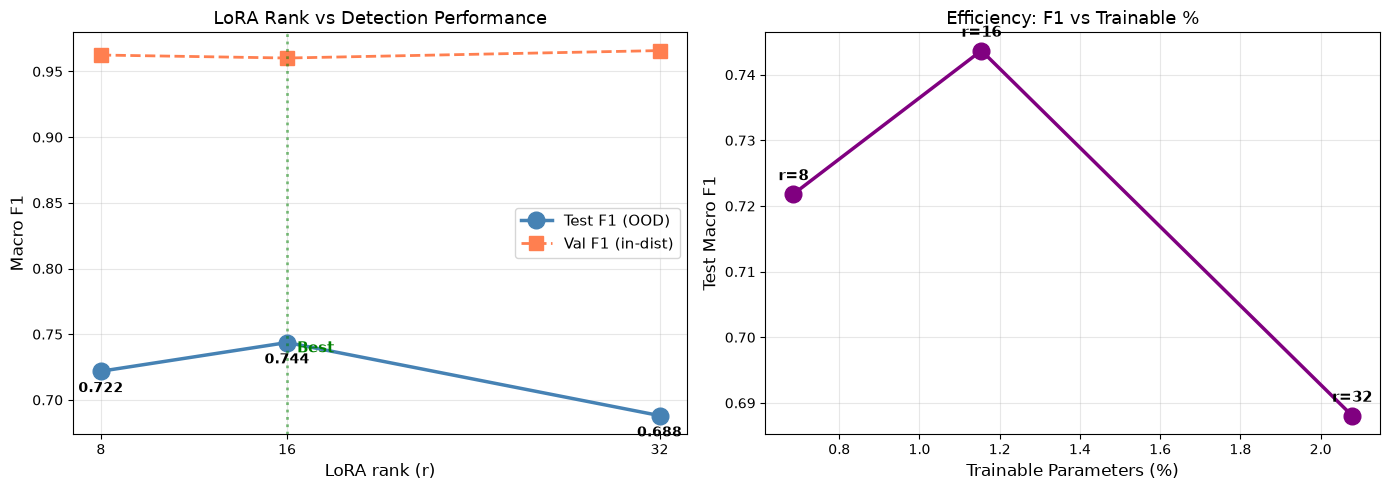

✅ Saved: ablation_lora_rank.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rs = [r['r'] for r in all_results]
test_f1s = [r['test_f1'] for r in all_results]
smish_recs = [r['smish_recall'] for r in all_results]
trainable_pcts = [r['trainable_pct'] for r in all_results]
val_f1s = [r['val_f1'] if r['val_f1'] else 0 for r in all_results]

# Plot 1: Test F1 vs r
axes[0].plot(rs, test_f1s, marker='o', linewidth=2.5, markersize=12,
             color='steelblue', label='Test F1 (OOD)')
axes[0].plot(rs, val_f1s, marker='s', linewidth=2, markersize=10,
             color='coral', linestyle='--', label='Val F1 (in-dist)')
axes[0].set_xlabel('LoRA rank (r)', fontsize=12)
axes[0].set_ylabel('Macro F1', fontsize=12)
axes[0].set_title('LoRA Rank vs Detection Performance', fontsize=13)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(rs)
axes[0].legend(fontsize=11)
for x, y in zip(rs, test_f1s):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords="offset points",
                     xytext=(0, -15), ha='center', fontsize=10, fontweight='bold')

# Highlight best
best_r = rs[np.argmax(test_f1s)]
axes[0].axvline(x=best_r, color='green', linestyle=':', alpha=0.5, linewidth=2)
axes[0].text(best_r, max(test_f1s)*0.99, '  Best', color='green', fontsize=11, fontweight='bold')

# Plot 2: Efficiency vs F1
axes[1].plot(trainable_pcts, test_f1s, marker='o', linewidth=2.5,
             markersize=12, color='purple')
axes[1].set_xlabel('Trainable Parameters (%)', fontsize=12)
axes[1].set_ylabel('Test Macro F1', fontsize=12)
axes[1].set_title('Efficiency: F1 vs Trainable %', fontsize=13)
axes[1].grid(alpha=0.3)
for x, y, r in zip(trainable_pcts, test_f1s, rs):
    axes[1].annotate(f'r={r}', (x, y), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("../results/figures/ablation_lora_rank.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ablation_lora_rank.png")

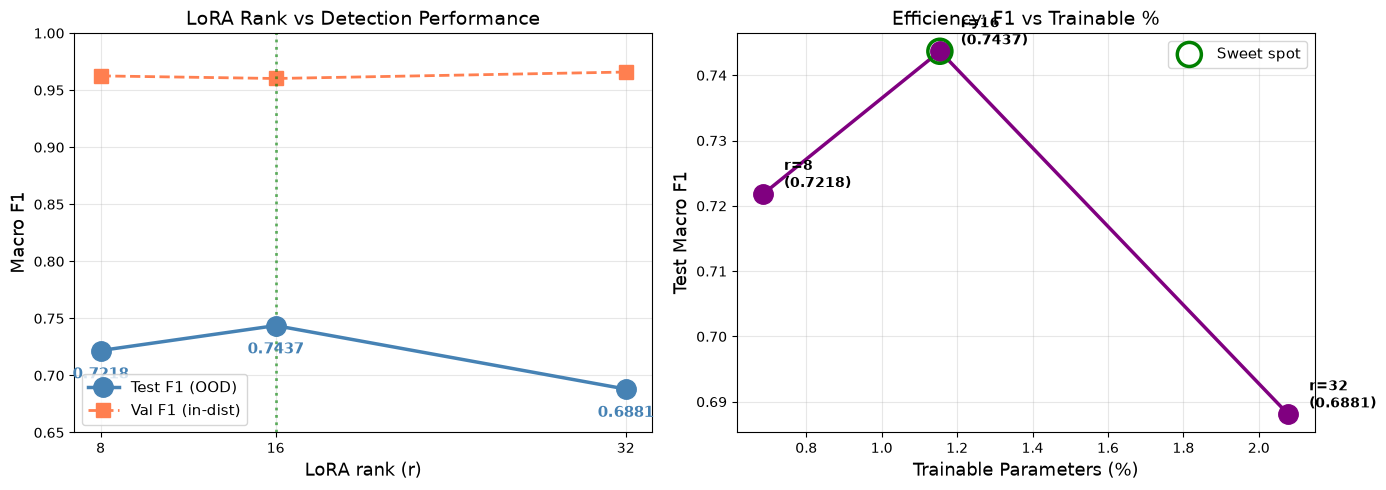

✅ Saved: ../results/figures/ablation_lora_rank.png


: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json

# Load results
with open("../results/ablation_lora_r.json", "r") as f:
    all_results = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rs = [r['r'] for r in all_results]
test_f1s = [r['test_f1'] for r in all_results]
smish_recs = [r['smish_recall'] for r in all_results]
trainable_pcts = [r['trainable_pct'] for r in all_results]
val_f1s = [r['val_f1'] if r['val_f1'] else 0 for r in all_results]

# ---------- Plot 1: r vs F1 ----------
axes[0].plot(rs, test_f1s, marker='o', linewidth=2.5, markersize=14,
             color='steelblue', label='Test F1 (OOD)', zorder=3)
axes[0].plot(rs, val_f1s, marker='s', linewidth=2, markersize=10,
             color='coral', linestyle='--', label='Val F1 (in-dist)', zorder=2)
axes[0].set_xlabel('LoRA rank (r)', fontsize=13)
axes[0].set_ylabel('Macro F1', fontsize=13)
axes[0].set_title('LoRA Rank vs Detection Performance', fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(rs)
axes[0].set_ylim(0.65, 1.0)
axes[0].legend(fontsize=11, loc='lower left')

# Annotate test F1 values
for x, y in zip(rs, test_f1s):
    axes[0].annotate(f'{y:.4f}', (x, y), textcoords="offset points",
                     xytext=(0, -20), ha='center', fontsize=11,
                     fontweight='bold', color='steelblue')

# Highlight best
best_r = rs[np.argmax(test_f1s)]
axes[0].axvline(x=best_r, color='green', linestyle=':', alpha=0.6, linewidth=2)

# ---------- Plot 2: Trainable % vs Test F1 ----------
axes[1].plot(trainable_pcts, test_f1s, marker='o', linewidth=2.5,
             markersize=14, color='purple', zorder=3)
axes[1].set_xlabel('Trainable Parameters (%)', fontsize=13)
axes[1].set_ylabel('Test Macro F1', fontsize=13)
axes[1].set_title('Efficiency: F1 vs Trainable %', fontsize=14)
axes[1].grid(alpha=0.3)

for x, y, r in zip(trainable_pcts, test_f1s, rs):
    axes[1].annotate(f'r={r}\n({y:.4f})', (x, y), textcoords="offset points",
                     xytext=(15, 5), ha='left', fontsize=10, fontweight='bold')

# Sweet spot marker
axes[1].scatter([trainable_pcts[1]], [test_f1s[1]], s=300, facecolors='none',
                edgecolors='green', linewidths=2.5, zorder=4, label='Sweet spot')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("../results/figures/ablation_lora_rank.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ../results/figures/ablation_lora_rank.png")